In [1]:
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# load and split the data
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

# compute the minimum and maximum on the training data
scaler = MinMaxScaler().fit(X_train)



In [2]:
# rescale the training data
X_train_scaled = scaler.transform(X_train)

svm = SVC()

# learn an SVM on the scaled training data
svm.fit(X_train_scaled, y_train)

# scale the test data and score the scaled data
X_test_scaled = scaler.transform(X_test)
print("Test score: {:.2f}".format(svm.score(X_test_scaled, y_test)))

Test score: 0.97


## Parameter Selection with Preprocessing

In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100],
              "gamma": [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best cross-validation accuracy: {:.2f}".format(grid.best_score_))
print("Best set score: {:.2f}".format(grid.score(X_test_scaled, y_test)))
print("Best parameters: ", grid.best_params_)

Best cross-validation accuracy: 0.98
Best set score: 0.97
Best parameters:  {'C': 1, 'gamma': 1}


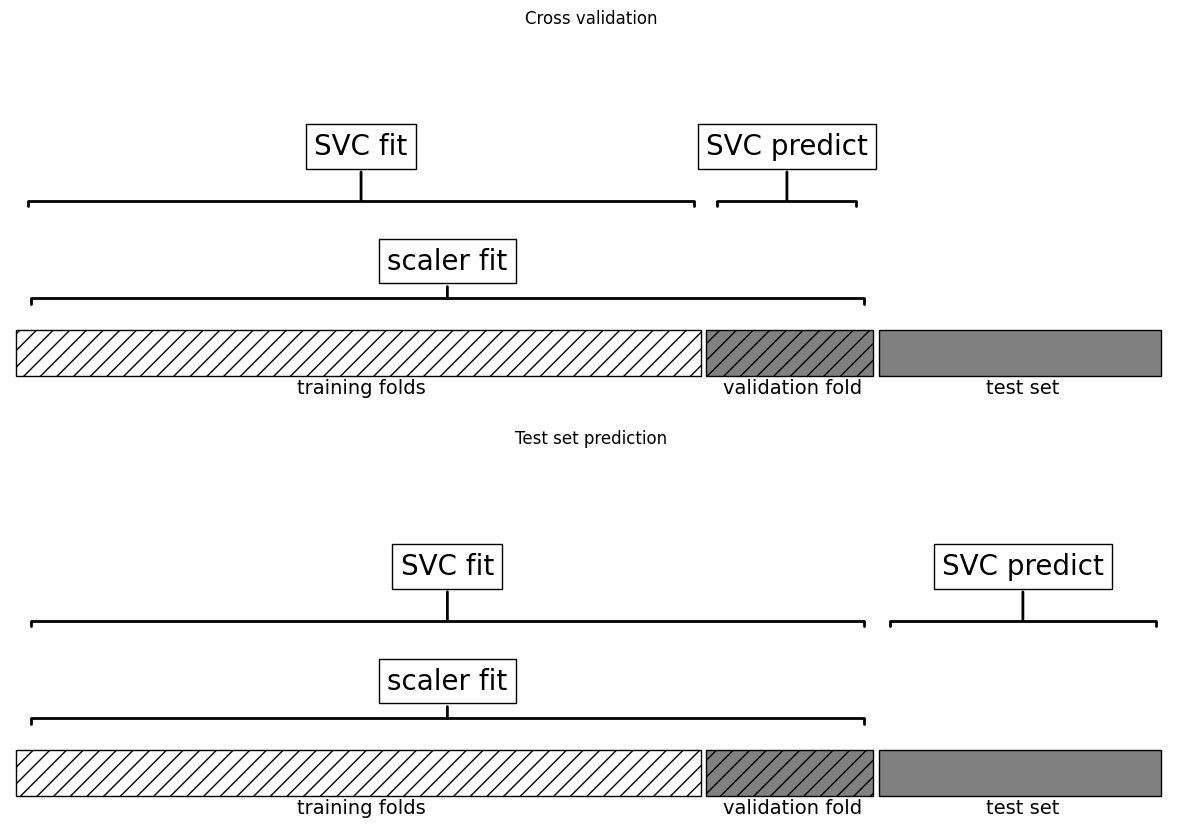

In [4]:
import mglearn

mglearn.plots.plot_improper_processing()

## Building Pipelines

In [5]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC())])

In [6]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [7]:
print("Test score: {:.2f}".format(pipeline.score(X_test, y_test)))

Test score: 0.97


In [8]:
param_grid = {"svm__C": [0.001, 0.01, 0.1, 1, 10, 100],
              "svm__gamma": [0.001, 0.01, 0.1, 1, 10, 100]}

In [9]:
grid_search_cv = GridSearchCV(pipeline, param_grid=param_grid, cv=5)
grid_search_cv.fit(X_train, y_train)

print("Best cross-validation accuracy: {:.2f}".format(grid_search_cv.best_score_))
print("Test set score: {:.2f}".format(grid_search_cv.score(X_test, y_test)))
print("Best parameters: {}".format(grid_search_cv.best_params_))

Best cross-validation accuracy: 0.98
Test set score: 0.97
Best parameters: {'svm__C': 1, 'svm__gamma': 1}


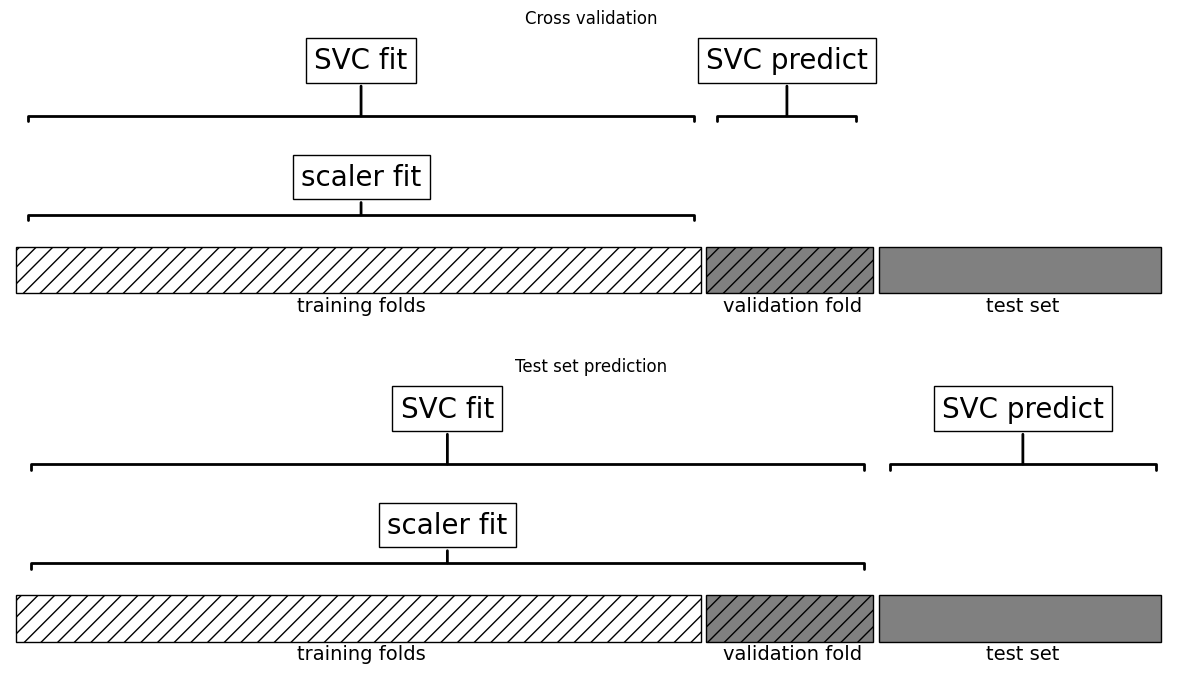

In [ ]:
mglearn.plots.plot_proper_processing()

## Illustrating Information Leakage !!!

In [12]:
import numpy as np

rnd = np.random.RandomState(seed=0)
X = rnd.normal(size=(100, 10000))
y = rnd.normal(size=(100,))

In [13]:
from sklearn.feature_selection import SelectPercentile, f_regression
select = SelectPercentile(score_func=f_regression, percentile=5).fit(X, y)
X_selected = select.transform(X)
print("X_selected.shape: {}".format(X_selected.shape))

X_selected.shape: (100, 500)


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
print("Cross-validation accuracy (cv only on ridge): {:.2f}".format(
np.mean(cross_val_score(Ridge(), X_selected, y, cv=5))))

Cross-validation accuracy (cv only on ridge): 0.91


In [15]:
pipe = Pipeline([("select", SelectPercentile(score_func=f_regression,
percentile=5)),
("ridge", Ridge())])
print("Cross-validation accuracy (pipeline): {:.2f}".format(
np.mean(cross_val_score(pipe, X, y, cv=5))))

Cross-validation accuracy (pipeline): -0.25


## The General Pipeline Interface

In [17]:
def fit(self, X, y):
    X_transformed = X
    for name, estimator in self.steps[:-1]:
        # iterate over all but the final step
        # fitand transform the data
        X_transformed = estimator.fit_transform(X_transformed, y)
    
    # fit the last step
    self.steps[-1][1].fit(X_transformed, y)
    return self

In [18]:
def predict(self, X):
    X_transformed = X
    
    for step in self.steps[:-1]:
        # iterate over all but the final step
        # transform the data 
        X_transformed = step[1].transform(X_transformed)

    # fit the last step
    return self.steps[-1][1].predict(X_transformed)

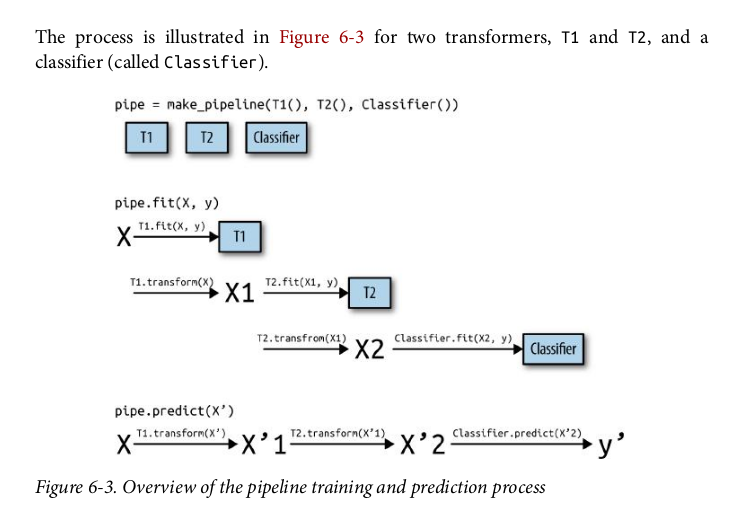

## Convenient Pipeline Creation with make_pipeline

In [19]:
from sklearn.pipeline import make_pipeline

# standard syntax
pipeline_long = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC(C=100))])

# abbreviated syntax
pipeline_short = make_pipeline(MinMaxScaler(), SVC(C=100))

In [20]:
print("Pipeline steps:\n{}".format(pipeline_short.steps))

Pipeline steps:
[('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pipeline = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())

print("Pipeline steps:\n{}".format(pipeline.steps))

Pipeline steps:
[('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]


In [22]:
# fit the pipeline defined before to the cancer dataset
pipeline.fit(cancer.data)

# extract the first two principal components from the "pca" step
components = pipeline.named_steps["pca"].components_

print("components.shape: {}".format(components.shape))

components.shape: (2, 30)


## Accessing Attributes in a Grid-Searched Pipeline

In [23]:
from sklearn.linear_model import LogisticRegression

pipeline = make_pipeline(StandardScaler(), LogisticRegression())


In [24]:
param_grid = {"logisticregression__C": [0.01, 0.1, 1, 10, 100]}

In [25]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=4)

grid_search_cv = GridSearchCV(pipeline, param_grid=param_grid, cv=5)
grid_search_cv.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'logisticregression__C': [0.01, 0.1, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [27]:
print("Best estimator:\n{}".format(grid_search_cv.best_estimator_))

Best estimator:
Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1))])


In [28]:
print("Logistic regression step:\n{}".format(grid_search_cv.best_estimator_.named_steps["logisticregression"]))

Logistic regression step:
LogisticRegression(C=1)


In [29]:
print("Logistic regression coefficients:\n{}".format(grid_search_cv.best_estimator_.named_steps["logisticregression"].coef_))

Logistic regression coefficients:
[[-0.4475566  -0.34609376 -0.41703843 -0.52889408 -0.15784407  0.60271339
  -0.71771325 -0.78367478  0.04847448  0.27478533 -1.29504052  0.05314385
  -0.69103766 -0.91925087 -0.14791795  0.46138699 -0.1264859  -0.10289486
   0.42812714  0.71492797 -1.08532414 -1.09273614 -0.85133685 -1.04104568
  -0.72839683  0.07656216 -0.83641023 -0.64928603 -0.6491432  -0.42968125]]


## Grid-Searching Preprocessing Steps and Model Parameters

In [37]:
from sklearn.datasets import fetch_california_housing

X, y = fetch_california_housing(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

from sklearn.preprocessing import PolynomialFeatures

pipeline = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(),
    Ridge()
)

In [38]:
param_grid = {"polynomialfeatures__degree": [1, 2, 3],
              "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

In [39]:
grid_search_cv = GridSearchCV(pipeline, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search_cv.fit(X_train, y_train)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'polynomialfeatures__degree': [1, 2, ...], 'ridge__alpha': [0.001, 0.01, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


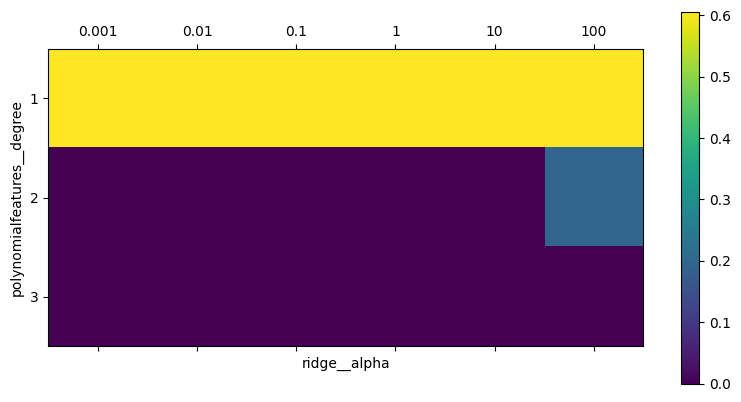

In [40]:
import matplotlib.pyplot as plt

plt.matshow(grid_search_cv.cv_results_["mean_test_score"].reshape(3, -1), vmin=0, cmap="viridis")
plt.xlabel("ridge__alpha")
plt.ylabel("polynomialfeatures__degree")
plt.xticks(range(len(param_grid["ridge__alpha"])), param_grid["ridge__alpha"])
plt.yticks(range(len(param_grid["polynomialfeatures__degree"])), param_grid["polynomialfeatures__degree"])
plt.colorbar()

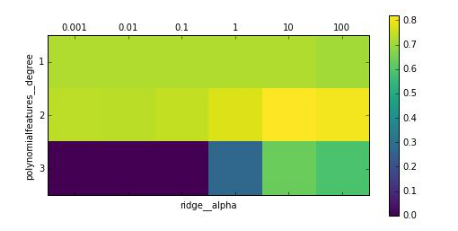

In [41]:

print("Best parameters: {}".format(grid_search_cv.best_params_))

Best parameters: {'polynomialfeatures__degree': 1, 'ridge__alpha': 10}


In [43]:
print("Test-set score: {:.2f}".format(grid_search_cv.score(X_test, y_test)))

Test-set score: 0.59


In [46]:
param_grid = {"ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
pipeline = make_pipeline(StandardScaler(), Ridge())
grid_search_cv = GridSearchCV(pipeline, param_grid, cv=5)
grid_search_cv.fit(X_train, y_train)
print("Score without poly features: {:.2f}".format(grid_search_cv.score(X_test, y_test)))

Score without poly features: 0.59


## Grid-Searching Which Model To Use

In [61]:
pipe = Pipeline([
    ('preprocessing', StandardScaler()),
    ('classifier', SVC())
])


In [62]:
from sklearn.ensemble import RandomForestClassifier

param_grid = [
    {
        'classifier': [SVC()],
        'preprocessing': [StandardScaler(), 'passthrough'],
        'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__C':     [0.001, 0.01, 0.1, 1, 10, 100],
    },
    {
        'classifier': [RandomForestClassifier(n_estimators=100)],
        'preprocessing': ['passthrough'],
        'classifier__max_features': [1, 2, 3],
    },
]


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)


grid_search_cv = GridSearchCV(pipe, param_grid=param_grid, cv=5)
grid_search_cv.fit(X_train, y_train)

print("Best params:\n{}\n".format(grid_search_cv.best_params_))
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Test-set score: {:.2f}".format(grid.score(X_test, y_test)))

Best params:
{'classifier': SVC(), 'classifier__C': 10, 'classifier__gamma': 0.01, 'preprocessing': StandardScaler()}

Best cross-validation score: 0.98
Test-set score: 0.37
